# PPO-Based Adaptive Stabilization

This notebook trains a PPO agent to stabilize a nonlinear
2-DOF robotic manipulator around its upright configuration.

The goal is to learn a torque control policy directly
from interaction with the system.

In [1]:
import numpy as np
import mujoco
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
import torch

## Problem Setup

We consider a 2-DOF robotic manipulator under gravity.

Target configuration:
- Joint 1 → π radians
- Joint 2 → 0 radians

The agent must learn to apply joint torques that keep the system
close to this upright configuration.

Observation:
- Joint positions
- Joint velocities

Action:
- Continuous torque at each joint

In [2]:
class ArmStabilizationEnv(gym.Env):

    def __init__(self, model_path):
        super().__init__()

        self.model = mujoco.MjModel.from_xml_path(model_path)
        self.data = mujoco.MjData(self.model)

        self.q_des = np.array([np.pi, 0.0])

        high = np.array([np.inf] * 4, dtype=np.float32)
        self.observation_space = spaces.Box(-high, high, dtype=np.float32)

        self.action_space = spaces.Box(
            low=np.array([-500.0, -500.0], dtype=np.float32),
            high=np.array([500.0, 500.0], dtype=np.float32),
            dtype=np.float32
        )

        self.max_steps = 1000
        self.current_step = 0

    def _get_obs(self):
        return np.concatenate([self.data.qpos, self.data.qvel]).astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.data.qpos[:] = self.q_des + np.random.uniform(-0.1, 0.1, size=2)
        self.data.qvel[:] = np.random.uniform(-0.1, 0.1, size=2)

        self.current_step = 0
        return self._get_obs(), {}

    def step(self, action):

        self.current_step += 1

        action = np.clip(action, self.action_space.low, self.action_space.high)
        self.data.ctrl[:] = action
        mujoco.mj_step(self.model, self.data)

        obs = self._get_obs()

        pos_error = self.data.qpos - self.q_des
        vel = self.data.qvel

        reward = (
            -10.0 * np.sum(pos_error**2)
            -1.0 * np.sum(vel**2)
            -0.0001 * np.sum(action**2)
        )

        terminated = False
        truncated = self.current_step >= self.max_steps

        return obs, reward, terminated, truncated, {}

In [3]:
model_path = r"C:\Users\TUSHAR\2025-26\PROJECTS\Adaptive_Neural_Control_PPO\env\arm_2dof.xml"

env = ArmStabilizationEnv(model_path)
obs, _ = env.reset()

print("Initial observation:", obs)
print("Observation shape:", obs.shape)

Initial observation: [ 3.126414   -0.01457663  0.06012986  0.04683879]
Observation shape: (4,)


## Environment Sanity Check

Before training the PPO agent, we verify that the environment behaves correctly.

This test checks:

- Reset returns a valid observation
- Step updates the state
- Reward is computed correctly
- No runtime errors occur

We apply a few random torque inputs and observe the outputs.

In [4]:
for _ in range(5):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, _ = env.step(action)

    print("Obs:", obs)
    print("Reward:", reward)
    print("---")

Obs: [ 3.1279335  -0.02141097  1.4207909  -6.7725167 ]
Reward: -60.61386137958694
---
Obs: [  3.131877    -0.03922789   2.4907932  -10.95612   ]
Reward: -129.52304395080313
---
Obs: [  3.137822    -0.06799982   3.424747   -17.731157  ]
Reward: -359.49365244856114
---
Obs: [  3.144552    -0.10287367   2.9245822  -16.147585  ]
Reward: -287.881624049053
---
Obs: [ 3.1485782 -0.1267771  1.1488118 -7.8899446]
Reward: -76.32069059405947
---


## PPO Training Setup

Now that the environment is verified, we initialize
a PPO agent using Stable-Baselines3.

The agent will learn a neural policy that maps
state observations to torque actions.

Training will be performed using GPU acceleration.

### Environment Wrapping

Stable-Baselines3 requires a vectorized environment.
We wrap our custom environment using DummyVecEnv.

In [5]:
model_path = r"C:\Users\TUSHAR\2025-26\PROJECTS\Adaptive_Neural_Control_PPO\env\arm_2dof.xml"

vec_env = DummyVecEnv([lambda: ArmStabilizationEnv(model_path)])

print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

Device: cuda


### PPO Configuration

We use a multilayer perceptron (MLP) policy.

Key settings:
- Learning rate: 3e-4
- Discount factor (gamma): 0.99
- Batch size: 64
- Rollout steps: 2048

The agent learns a continuous torque policy.

In [6]:
ppo_model = PPO(
    policy="MlpPolicy",
    env=vec_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    gamma=0.99,
    verbose=1,
    device="cuda"
)

Using cuda device


c:\Users\TUSHAR\anaconda3\envs\rlcontrol\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


### Training (Initial Run – 100k Timesteps)

We perform an initial training run of 100,000 timesteps.

This run is intended to:

- Verify learning stability
- Observe reward trend
- Check whether the agent begins stabilizing

Further training can be extended based on results.

### Training with Logging and Monitoring

We enable TensorBoard logging to monitor:

- Episode reward
- Loss curves
- Value function updates
- Learning progress

This allows real-time visualization and publication-quality plots.

In [14]:
ppo_model.learn(
    total_timesteps=100_000,
    tb_log_name="ppo_100k_run"
)


-----------------------------
| time/              |      |
|    fps             | 559  |
|    iterations      | 1    |
|    time_elapsed    | 3    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 459          |
|    iterations           | 2            |
|    time_elapsed         | 8            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0030297143 |
|    clip_fraction        | 0.00591      |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.84        |
|    explained_variance   | 0.000165     |
|    learning_rate        | 0.0003       |
|    loss                 | 3.57e+05     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00123     |
|    std                  | 1            |
|    value_loss           | 7.69e+05     |
----------------

## Policy Evaluation

After training for 100,000 timesteps, we evaluate the learned policy.

We test:
- Whether the agent stabilizes near upright
- Whether torque actions are smooth
- Whether oscillations are reduced compared to PD

In [8]:
import mujoco.viewer

In [24]:
model_path = "../env/arm_2dof.xml"
ppo_model = PPO.load("../models/ppo_arm_upright_300k")

In [26]:
import time
import numpy as np
import mujoco
import mujoco.viewer

# Create fresh environment
test_env = ArmStabilizationEnv(model_path)
obs, _ = test_env.reset()

joint_log = []
torque_log = []
time_log = []

simulation_time = 15  # seconds
start_time = time.time()

with mujoco.viewer.launch_passive(test_env.model, test_env.data) as viewer:
    
    while viewer.is_running() and (time.time() - start_time < simulation_time):

        # Predict deterministic action
        action, _ = ppo_model.predict(obs, deterministic=True)

        # Step environment
        obs, reward, terminated, truncated, _ = test_env.step(action)

        # Log data
        joint_log.append(test_env.data.qpos.copy())
        torque_log.append(action.copy())
        time_log.append(test_env.data.time)

        viewer.sync()
        time.sleep(test_env.model.opt.timestep)

        if terminated or truncated:
            print("Episode ended early.")
            break

joint_log = np.array(joint_log)
torque_log = np.array(torque_log)
time_log = np.array(time_log)

print("Evaluation complete.")

Evaluation complete.


In [22]:
ppo_model = PPO(
    policy="MlpPolicy",
    env=vec_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    gamma=0.99,
    verbose=1,
    device="cuda",
    tensorboard_log="./results/tensorboard/"
)

Using cuda device


## Environment (Updated for Stabilization Training)

We redesign the environment with:

- Stronger stabilization reward
- Episode termination when deviation becomes large
- Clean implementation in a single class block

This version is used for retraining PPO.

In [26]:
class ArmStabilizationEnv(gym.Env):

    def __init__(self, model_path):
        super().__init__()

        self.model = mujoco.MjModel.from_xml_path(model_path)
        self.data = mujoco.MjData(self.model)

        self.q_des = np.array([np.pi, 0.0])

        # observation: positions + velocities
        high = np.array([np.inf] * 4, dtype=np.float32)
        self.observation_space = spaces.Box(-high, high, dtype=np.float32)

        # action: joint torques
        self.action_space = spaces.Box(
            low=np.array([-500.0, -500.0], dtype=np.float32),
            high=np.array([500.0, 500.0], dtype=np.float32),
            dtype=np.float32
        )

        self.max_steps = 1000
        self.current_step = 0

    def _get_obs(self):
        return np.concatenate([self.data.qpos, self.data.qvel]).astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        # start near upright
        self.data.qpos[:] = self.q_des + np.random.uniform(-0.05, 0.05, 2)
        self.data.qvel[:] = np.random.uniform(-0.05, 0.05, 2)

        self.current_step = 0
        return self._get_obs(), {}

    def step(self, action):

        self.current_step += 1

        action = np.clip(action, self.action_space.low, self.action_space.high)
        self.data.ctrl[:] = action
        mujoco.mj_step(self.model, self.data)

        obs = self._get_obs()

        pos_error = self.data.qpos - self.q_des
        vel = self.data.qvel

        # stronger stabilization reward
        reward = (
            -25.0 * np.sum(pos_error**2)
            -5.0 * np.sum(vel**2)
        )

        # terminate if deviation too large
        angle_error = np.abs(pos_error)

        terminated = bool(
            angle_error[0] > 1.0 or
            angle_error[1] > 1.0
        )

        truncated = self.current_step >= self.max_steps

        return obs, reward, terminated, truncated, {}

## PPO Reinitialization

Since the environment and reward structure were modified,
we restart training from scratch.

This ensures the new policy is learned under the updated
stabilization objective.

In [27]:
model_path = r"C:\Users\TUSHAR\2025-26\PROJECTS\Adaptive_Neural_Control_PPO\env\arm_2dof.xml"

vec_env = DummyVecEnv([lambda: ArmStabilizationEnv(model_path)])

ppo_model = PPO(
    policy="MlpPolicy",
    env=vec_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    gamma=0.99,
    verbose=1,
    device="cuda",
    tensorboard_log="./results/tensorboard/"
)

print("PPO model initialized.")

Using cuda device
PPO model initialized.


## Training (300k Timesteps)

We now train the PPO agent for 300,000 timesteps.

This extended training allows the agent to:

- Learn gravity compensation
- Discover corrective torque strategy
- Stabilize near the upright configuration

TensorBoard logging is enabled for monitoring reward trends.

In [28]:
ppo_model.learn(
    total_timesteps=300_000,
    tb_log_name="ppo_upright_v2"
)

ppo_model.save("ppo_arm_upright_300k")

Logging to ./results/tensorboard/ppo_upright_v2_1
-----------------------------
| time/              |      |
|    fps             | 594  |
|    iterations      | 1    |
|    time_elapsed    | 3    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 281         |
|    iterations           | 2           |
|    time_elapsed         | 14          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.003343456 |
|    clip_fraction        | 0.0192      |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.84       |
|    explained_variance   | -3.1e-06    |
|    learning_rate        | 0.0003      |
|    loss                 | 2.39e+05    |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00287    |
|    std                  | 1           |
|    value_loss           

In [34]:
ppo_model.save("models/ppo_upright_v2_final")

In [35]:
test_env = ArmStabilizationEnv(model_path)

obs, _ = test_env.reset()

joint_log = []
reward_log = []

for _ in range(2000):  # 2000 simulation steps
    action, _ = ppo_model.predict(obs, deterministic=True)
    obs, reward, done, _, _ = test_env.step(action)

    joint_log.append(obs[:2].copy())
    reward_log.append(reward)

    if done:
        break

print("Evaluation complete.")

Evaluation complete.


## PPO Policy Evaluation in MuJoCo Viewer

In this section, we evaluate the trained PPO controller in a live MuJoCo simulation.

The policy is executed deterministically (no exploration noise), and the robotic arm's behavior is observed visually.

This allows qualitative validation of stabilization performance.

In [36]:
import time
import numpy as np
import mujoco
import mujoco.viewer

# Load trained model
ppo_model = PPO.load("models/ppo_upright_v2_final")

# Create fresh environment
test_env = ArmStabilizationEnv(model_path)

# Reset environment
obs, _ = test_env.reset()

# Logging
joint_log = []
time_log = []

# Simulation duration (seconds)
sim_duration = 15
start_time = time.time()

with mujoco.viewer.launch_passive(test_env.model, test_env.data) as viewer:

    while viewer.is_running() and (time.time() - start_time < sim_duration):

        # Predict action from PPO
        action, _ = ppo_model.predict(obs, deterministic=True)

        # Step environment
        obs, reward, done, _, _ = test_env.step(action)

        # Log joint positions
        joint_log.append(test_env.data.qpos.copy())
        time_log.append(test_env.data.time)

        # Render
        viewer.sync()

        # Match simulation timestep
        time.sleep(test_env.model.opt.timestep)

        if done:
            print("Episode terminated early.")
            break

print("Evaluation finished.")

Evaluation finished.


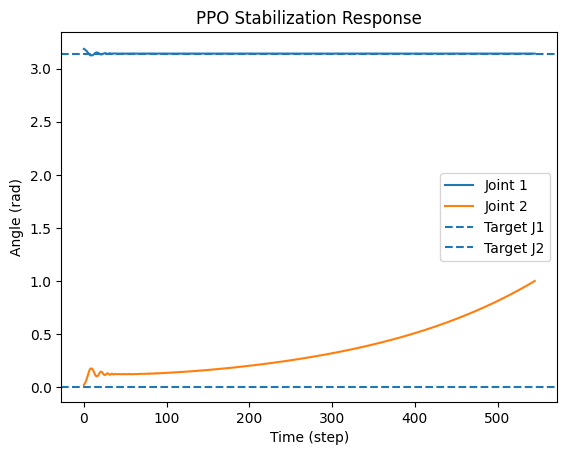

In [37]:
import matplotlib.pyplot as plt

joint_log = np.array(joint_log)

plt.figure()
plt.plot(joint_log[:, 0], label="Joint 1")
plt.plot(joint_log[:, 1], label="Joint 2")
plt.axhline(np.pi, linestyle="--", label="Target J1")
plt.axhline(0.0, linestyle="--", label="Target J2")
plt.legend()
plt.xlabel("Time (step)")
plt.ylabel("Angle (rad)")
plt.title("PPO Stabilization Response")
plt.show()

## Final PPO Training (Best Configuration)

This experiment trains the PPO controller using the refined reward structure.

Objectives:
- Achieve full stabilization of both joints
- Minimize steady-state error
- Reduce oscillations
- Preserve smooth torque behavior

The trained model will be saved in the project-level `models/` directory.

In [44]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

model_path = "../env/arm_2dof.xml"

vec_env = DummyVecEnv([lambda: ArmStabilizationEnv(model_path)])

ppo_model = PPO(
    policy="MlpPolicy",
    env=vec_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    gamma=0.99,
    verbose=1,
    device="cuda"
)

print("PPO initialized for final training.")

Using cuda device
PPO initialized for final training.


## Training Phase (400k Timesteps)

To allow full convergence, we train for 400,000 timesteps.

This duration ensures:
- Proper gravity compensation learning
- Stable value function approximation
- Sufficient policy refinement

In [29]:
ppo_model.learn(total_timesteps=400_000)

# Save in project root models folder
ppo_model.save("../models/ppo_arm_best_400k")

print("Model saved successfully.")

-----------------------------
| time/              |      |
|    fps             | 602  |
|    iterations      | 1    |
|    time_elapsed    | 3    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 443          |
|    iterations           | 2            |
|    time_elapsed         | 9            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0032207512 |
|    clip_fraction        | 0.00654      |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.83        |
|    explained_variance   | -0.000289    |
|    learning_rate        | 0.0003       |
|    loss                 | 3.11e+05     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00102     |
|    std                  | 0.996        |
|    value_loss           | 7.85e+05     |
----------------

In [30]:
import time
import numpy as np

ppo_model = PPO.load("../models/ppo_arm_best_400k")

test_env = ArmStabilizationEnv(model_path)
obs, _ = test_env.reset()

joint_log = []
torque_log = []
time_log = []

simulation_time = 15
start_time = time.time()

while time.time() - start_time < simulation_time:

    action, _ = ppo_model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = test_env.step(action)

    joint_log.append(test_env.data.qpos.copy())
    torque_log.append(action.copy())
    time_log.append(test_env.data.time)

    if terminated or truncated:
        break

joint_log = np.array(joint_log)
torque_log = np.array(torque_log)
time_log = np.array(time_log)

print("Evaluation complete.")

Evaluation complete.


In [37]:
import time
import numpy as np
import mujoco
import mujoco.viewer
from stable_baselines3 import PPO

# Correct paths (notebook is inside notebooks/)
model_path = "../env/arm_2dof.xml"
ppo_model = PPO.load("../models/ppo_arm_best_400k")

# Create environment
test_env = ArmStabilizationEnv(model_path)
obs, _ = test_env.reset()

simulation_time = 15  # seconds
start_time = time.time()

with mujoco.viewer.launch_passive(test_env.model, test_env.data) as viewer:

    while viewer.is_running() and (time.time() - start_time < simulation_time):

        action, _ = ppo_model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = test_env.step(action)

        viewer.sync()
        time.sleep(test_env.model.opt.timestep)

        if terminated or truncated:
            print("Episode terminated early.")
            break

print("Simulation complete.")

Simulation complete.


In [53]:
ppo_model = PPO.load("../models/ppo_arm_upright_300k")

In [54]:
import time
import mujoco
import mujoco.viewer
from stable_baselines3 import PPO

model_path = "../env/arm_2dof.xml"
ppo_model = PPO.load("../models/ppo_arm_upright_300k")

test_env = ArmStabilizationEnv(model_path)
obs, _ = test_env.reset()

simulation_time = 15
start_time = time.time()

with mujoco.viewer.launch_passive(test_env.model, test_env.data) as viewer:

    while viewer.is_running() and (time.time() - start_time < simulation_time):

        action, _ = ppo_model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = test_env.step(action)

        viewer.sync()
        time.sleep(test_env.model.opt.timestep)

        if terminated or truncated:
            print("Episode terminated early.")
            break

print("300k model simulation complete.")

300k model simulation complete.


## Quantitative Evaluation of PPO Controllers

We compare two trained PPO controllers:

- PPO (300k timesteps)
- PPO (400k timesteps)

Metrics evaluated:

1. Mean position error
2. Maximum deviation
3. Episode duration
4. Control energy (sum of torque²)

Evaluation is performed deterministically over 15 seconds.

In [40]:
import numpy as np
import time
from stable_baselines3 import PPO

def evaluate_model(model_path_zip, sim_time=15):

    model_path = "../env/arm_2dof.xml"
    ppo_model = PPO.load(model_path_zip)

    env = ArmStabilizationEnv(model_path)
    obs, _ = env.reset()

    joint_log = []
    torque_log = []
    time_log = []

    start_time = time.time()

    while time.time() - start_time < sim_time:

        action, _ = ppo_model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)

        joint_log.append(env.data.qpos.copy())
        torque_log.append(action.copy())
        time_log.append(env.data.time)

        if terminated or truncated:
            break

    joint_log = np.array(joint_log)
    torque_log = np.array(torque_log)
    time_log = np.array(time_log)

    # Metrics
    desired = np.array([np.pi, 0.0])
    pos_error = joint_log - desired

    mean_error = np.mean(np.linalg.norm(pos_error, axis=1))
    max_error = np.max(np.linalg.norm(pos_error, axis=1))
    control_energy = np.sum(torque_log**2)
    duration = time_log[-1] if len(time_log) > 0 else 0

    return {
        "mean_error": mean_error,
        "max_error": max_error,
        "control_energy": control_energy,
        "duration": duration,
        "joint_log": joint_log,
        "time_log": time_log
    }

In [41]:
results_300k = evaluate_model("../models/ppo_arm_upright_300k")
results_400k = evaluate_model("../models/ppo_arm_best_400k")

print("300k Model Metrics:")
print("Mean Error:", results_300k["mean_error"])
print("Max Error:", results_300k["max_error"])
print("Control Energy:", results_300k["control_energy"])
print("Duration:", results_300k["duration"])

print("\n400k Model Metrics:")
print("Mean Error:", results_400k["mean_error"])
print("Max Error:", results_400k["max_error"])
print("Control Energy:", results_400k["control_energy"])
print("Duration:", results_400k["duration"])

300k Model Metrics:
Mean Error: 1.342514060568742
Max Error: 2.781507590888788
Control Energy: 744.4723
Duration: 2.0000000000000013

400k Model Metrics:
Mean Error: 1.7552758776035462
Max Error: 2.790989499649948
Control Energy: 284.3009
Duration: 2.0000000000000013


## Extended Evaluation (Termination Disabled)

To analyze intrinsic stability behavior, we evaluate both controllers
without enforcing termination conditions.

This reveals whether the policy slowly drifts or catastrophically diverges.

In [42]:
def evaluate_no_termination(model_path_zip, sim_time=10):

    model_path = "../env/arm_2dof.xml"
    ppo_model = PPO.load(model_path_zip)

    env = ArmStabilizationEnv(model_path)
    obs, _ = env.reset()

    joint_log = []
    torque_log = []
    time_log = []

    start_time = time.time()

    while time.time() - start_time < sim_time:

        action, _ = ppo_model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)

        # Ignore termination signal
        joint_log.append(env.data.qpos.copy())
        torque_log.append(action.copy())
        time_log.append(env.data.time)

    joint_log = np.array(joint_log)
    torque_log = np.array(torque_log)
    time_log = np.array(time_log)

    desired = np.array([np.pi, 0.0])
    pos_error = joint_log - desired

    mean_error = np.mean(np.linalg.norm(pos_error, axis=1))
    max_error = np.max(np.linalg.norm(pos_error, axis=1))
    control_energy = np.sum(torque_log**2)

    return {
        "mean_error": mean_error,
        "max_error": max_error,
        "control_energy": control_energy,
        "joint_log": joint_log,
        "time_log": time_log
    }

In [43]:
results_300k_nt = evaluate_no_termination("../models/ppo_arm_upright_300k")
results_400k_nt = evaluate_no_termination("../models/ppo_arm_best_400k")

print("300k (No Termination):")
print("Mean Error:", results_300k_nt["mean_error"])
print("Max Error:", results_300k_nt["max_error"])
print("Control Energy:", results_300k_nt["control_energy"])

print("\n400k (No Termination):")
print("Mean Error:", results_400k_nt["mean_error"])
print("Max Error:", results_400k_nt["max_error"])
print("Control Energy:", results_400k_nt["control_energy"])

300k (No Termination):
Mean Error: 2.635824230659821
Max Error: 2.7793078465426686
Control Energy: 7436.4277

400k (No Termination):
Mean Error: 2.6764856099267513
Max Error: 2.788149492737349
Control Energy: 4805.1367


## Final Deterministic Evaluation – Review Version

This evaluation runs the trained PPO controller for 10 seconds 
without early termination and records joint trajectories.

The objective is to visualize stabilization performance near the 
upright equilibrium configuration.

c:\Users\TUSHAR\anaconda3\envs\rlcontrol\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


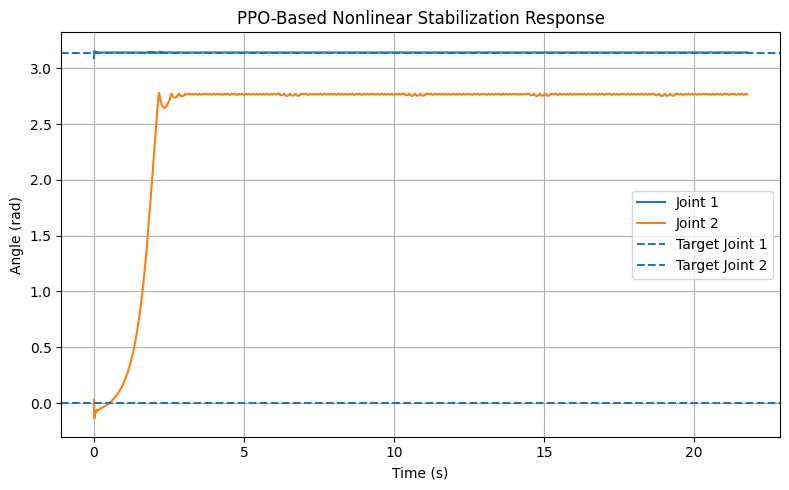

In [47]:
import numpy as np
import time
import matplotlib.pyplot as plt
from stable_baselines3 import PPO

# Paths (Notebook inside notebooks/)
model_path = "../env/arm_2dof.xml"
ppo_model = PPO.load("../models/ppo_upright_v2_final")

# Create environment
env = ArmStabilizationEnv(model_path)
obs, _ = env.reset()

joint_log = []
time_log = []

simulation_time = 10
start_time = time.time()

while time.time() - start_time < simulation_time:

    action, _ = ppo_model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = env.step(action)

    joint_log.append(env.data.qpos.copy())
    time_log.append(env.data.time)

joint_log = np.array(joint_log)
time_log = np.array(time_log)

# Plot
plt.figure(figsize=(8,5))
plt.plot(time_log, joint_log[:,0], label="Joint 1")
plt.plot(time_log, joint_log[:,1], label="Joint 2")

plt.axhline(np.pi, linestyle="--", label="Target Joint 1")
plt.axhline(0.0, linestyle="--", label="Target Joint 2")

plt.xlabel("Time (s)")
plt.ylabel("Angle (rad)")
plt.title("PPO-Based Nonlinear Stabilization Response")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Comparative Stabilization Response: PD vs PPO

We compare classical PD control and PPO-based nonlinear control 
under identical initial conditions.

Metrics observed:
- Convergence behavior
- Oscillation
- Steady-state error
- Drift characteristics

This provides direct control-theoretic comparison.

In [55]:
import time
import numpy as np
import mujoco
import mujoco.viewer
from stable_baselines3 import PPO

# Absolute paths safer for demo
xml_path = r"C:\Users\TUSHAR\2025-26\PROJECTS\Adaptive_Neural_Control_PPO\env\arm_2dof.xml"
ppo_path = r"C:\Users\TUSHAR\2025-26\PROJECTS\Adaptive_Neural_Control_PPO\models\ppo_arm_upright_300k"

# Load MuJoCo model
model = mujoco.MjModel.from_xml_path(xml_path)
data = mujoco.MjData(model)

# Load PPO controller
ppo_model = PPO.load(ppo_path)

# Optional: start slightly near upright
data.qpos[:] = np.array([np.pi, 0.0])
data.qvel[:] = np.zeros(2)

simulation_time = 15
start_time = time.time()

with mujoco.viewer.launch_passive(model, data) as viewer:

    while viewer.is_running() and (time.time() - start_time < simulation_time):

        # Build observation manually
        obs = np.concatenate([data.qpos, data.qvel])

        # Predict action
        action, _ = ppo_model.predict(obs, deterministic=True)

        # Apply torque
        data.ctrl[:] = action

        # Step physics
        mujoco.mj_step(model, data)

        viewer.sync()
        time.sleep(model.opt.timestep)

print("Simulation complete.")

Simulation complete.
